# **Predicting Melbourne House Prices**

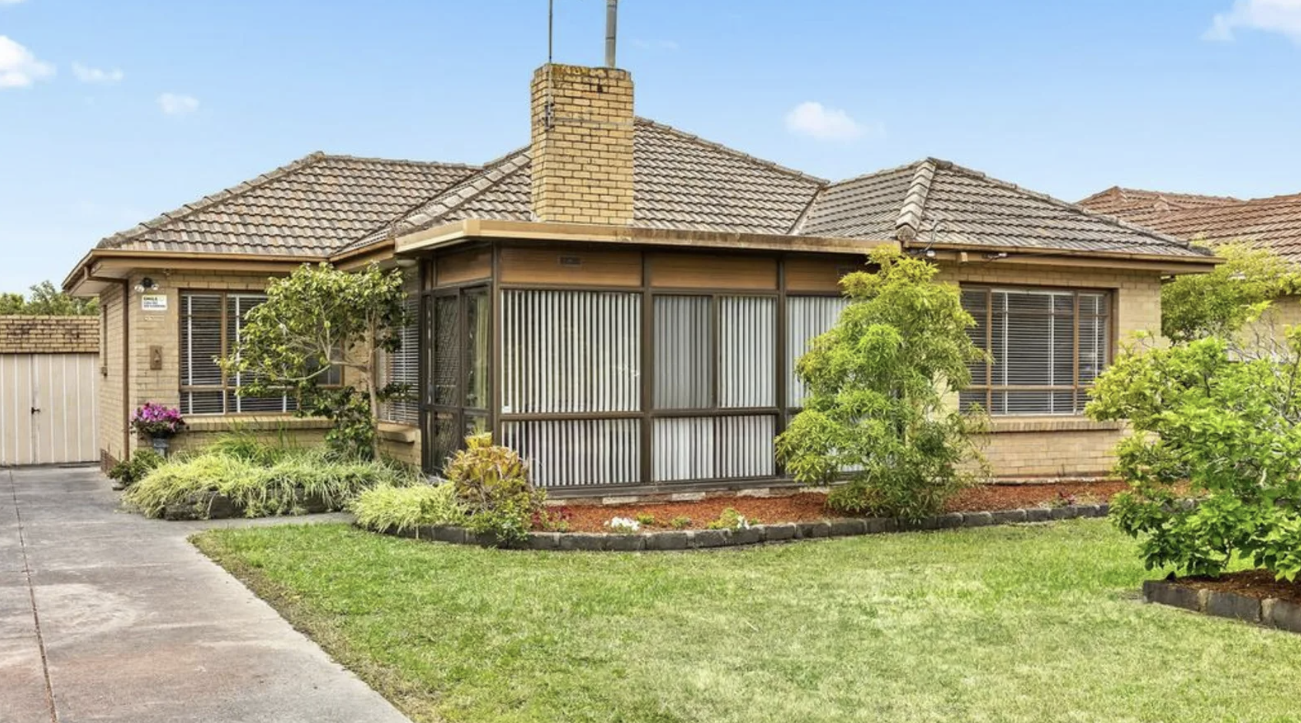

Melbourne is the largest city in Victora, Australia and continues to grow rapidly. Over the past several years Melbourne has become one of the most expensive places to buy a home in the world, cosistently sitting in the top ten according to multiple sources. This has caused even modest homes (like the one pictured above) to become highly unaffordable and difficult to obtain.

### **The Aim**

By utilising expoloratory data analysis and machine learning, this project aims to accurately predict house prices in Melbourne using this [dataset]("https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market") which includes variables such as location, number of rooms and property type.

### **The Objective**

If we were working at a real estate firm, the business objective might be to use the outputs of our model(s) to determine whether or not to invest in certain areas. However, because this is a personal project we will use our findings for our own interests.

### **The System Design**

Now that we have our aim and objective, we determine the types of models to use.

**Supervised or Unsupervised Learning?**
- This is a <u>*supervised learning*</u> task, as we can train the model with labelled examples

**Classification, Regression or something else?**
- This would be a <u>*regression*</u> task as the model will predict a value (House prices)
    - Furthermore, this would be a <u>*univariate*</u>, <u>*multiple regression*</u> task as we want to predict a single value based on multiple features

**Online Learning or Batch Learning?**
- This is a <u>*batch Learning*</u> task as we don't have a continuous stream of data coming in, and the size of the data is small enough to store in memory.



### **The Performance Measure**

For this task, we will use RSME(Root Mean Squared Error) as our main performance measure as it is typically used for regression tasks.

### **The Data**

This project will be using [this dataset]("https://www.kaggle.com/datasets/anthonypino/melbourne-housing-market") which includes the following:

- Suburb
- Address
- Rooms (The number of rooms)
- Type
    - br = bedroom(s)
    - br - bedroom(s);
    - h - house,cottage,villa, semi,terrace;
    - u - unit, duplex;
    - t - townhouse;
    - dev site - development site;
    - o res - other residential.
- Price (In Australian Dollars) *this is our target variable i.e the thing we're trying to predict*
- Method
    - S - property sold;
    - SP - property sold prior;
    - PI - property passed in;
    - PN - sold prior not disclosed;
    - SN - sold not disclosed;
    - NB - no bid;
    - VB - vendor bid;
    - W - withdrawn prior to auction;
    - SA - sold after auction;
    - SS - sold after auction price not disclosed.
    - N/A - price or highest bid not available.
- SellerG (Real estate agent)
- Date (Date Sold)
- Distance (Distance to CBD in km)
- Postcode
- Regionname (General Region (West, North West, North, North east …etc))
- Propertycount (Number of properties that exist in the suburb)
- Bedroom2 (Scraped # of Bedrooms (from different source))
- Bathroom (Number of Bathrooms)
- Car (Number of carspots)
- Landsize (Land Size in Metres)
- BuildingArea (Building Size in Metres)
- YearBuilt (Year the house was built)
- CouncilArea (Governing council for the area)
- Latitude
- Longitude

### **Importing Libraries**

We'll import the libraries here 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

Load the data:

In [ ]:
housing = pd.read_csv("C:/Users/jungn/OneDrive/Documents/Projects/Melbourne-Housing-Price-Prediction/data/Melbourne_housing_FULL.csv")

### **Exploratory Data Analysis**

We want to know about the data itself:
- Does it have missing values? (if so which variables?)
- Does it have duplicate rows?
- Does it contain categorical variables?
- What is the shape of the data (How many rows and columns?)

We also want to get an idea of the relationships and the overall "behaviour" of the data

Taking a quick peek:

In [ ]:
housing.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

In [ ]:
housing.shape

(34857, 21)

Seems like there's a total of eight categorical variables, such as CouncilArea, SellerG and Suburb. We will deal with these later.

We also see that there are 21 variables, 14 of which have at one or more missing values(Non-Null counts lower than 34857). We will have to deal with these as well.

In [ ]:
housing.duplicated().sum()

np.int64(1)

We have one duplicate row

In [ ]:
housing[housing.duplicated(keep=False)]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
15857,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,17/06/2017,15.4,3131.0,...,3.0,2.0,405.0,226.0,2000.0,Manningham City Council,-37.82678,145.16777,Eastern Metropolitan,4973.0
15858,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,17/06/2017,15.4,3131.0,...,3.0,2.0,405.0,226.0,2000.0,Manningham City Council,-37.82678,145.16777,Eastern Metropolitan,4973.0


Found it :)

In [ ]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,34857.0,3.031012e+00,0.969933,1.00000,2.00000,3.0000,4.000000e+00,1.600000e+01
Price,27247.0,1.050173e+06,641467.130105,85000.00000,635000.00000,870000.0000,1.295000e+06,1.120000e+07
Distance,34856.0,1.118493e+01,6.788892,0.00000,6.40000,10.3000,1.400000e+01,4.810000e+01
Postcode,34856.0,3.116063e+03,109.023903,3000.00000,3051.00000,3103.0000,3.156000e+03,3.978000e+03
Bedroom2,26640.0,3.084647e+00,0.980690,0.00000,2.00000,3.0000,4.000000e+00,3.000000e+01
Bathroom,26631.0,1.624798e+00,0.724212,0.00000,1.00000,2.0000,2.000000e+00,1.200000e+01
Car,26129.0,1.728845e+00,1.010771,0.00000,1.00000,2.0000,2.000000e+00,2.600000e+01
Landsize,23047.0,5.935990e+02,3398.841946,0.00000,224.00000,521.0000,6.700000e+02,4.330140e+05
BuildingArea,13742.0,1.602564e+02,401.267060,0.00000,102.00000,136.0000,1.880000e+02,4.451500e+04
YearBuilt,15551.0,1.965290e+03,37.328178,1196.00000,1940.00000,1970.0000,2.000000e+03,2.106000e+03


We see some interesting things, for example the min value of "YearBuilt" is 1196 and the max is 2106 which doesn't make sense at all. These anomalies will be considered as missing data.

We also see that the min value for some variables are 0. This would make sense for variables like "Car" and  "Distance", however it would not make sense for variables such as "LandSize", "BuildingArea", "Bathroom" and "Bedroom". These variables will be considered as missing values if they have 0. 

In [ ]:
cat_cols = ['Suburb', 'Address', 'Type', 'Method', 
            'SellerG', 'Date', 'CouncilArea', 'Regionname']
num_cols = [col for col in housing.columns if col not in cat_cols]

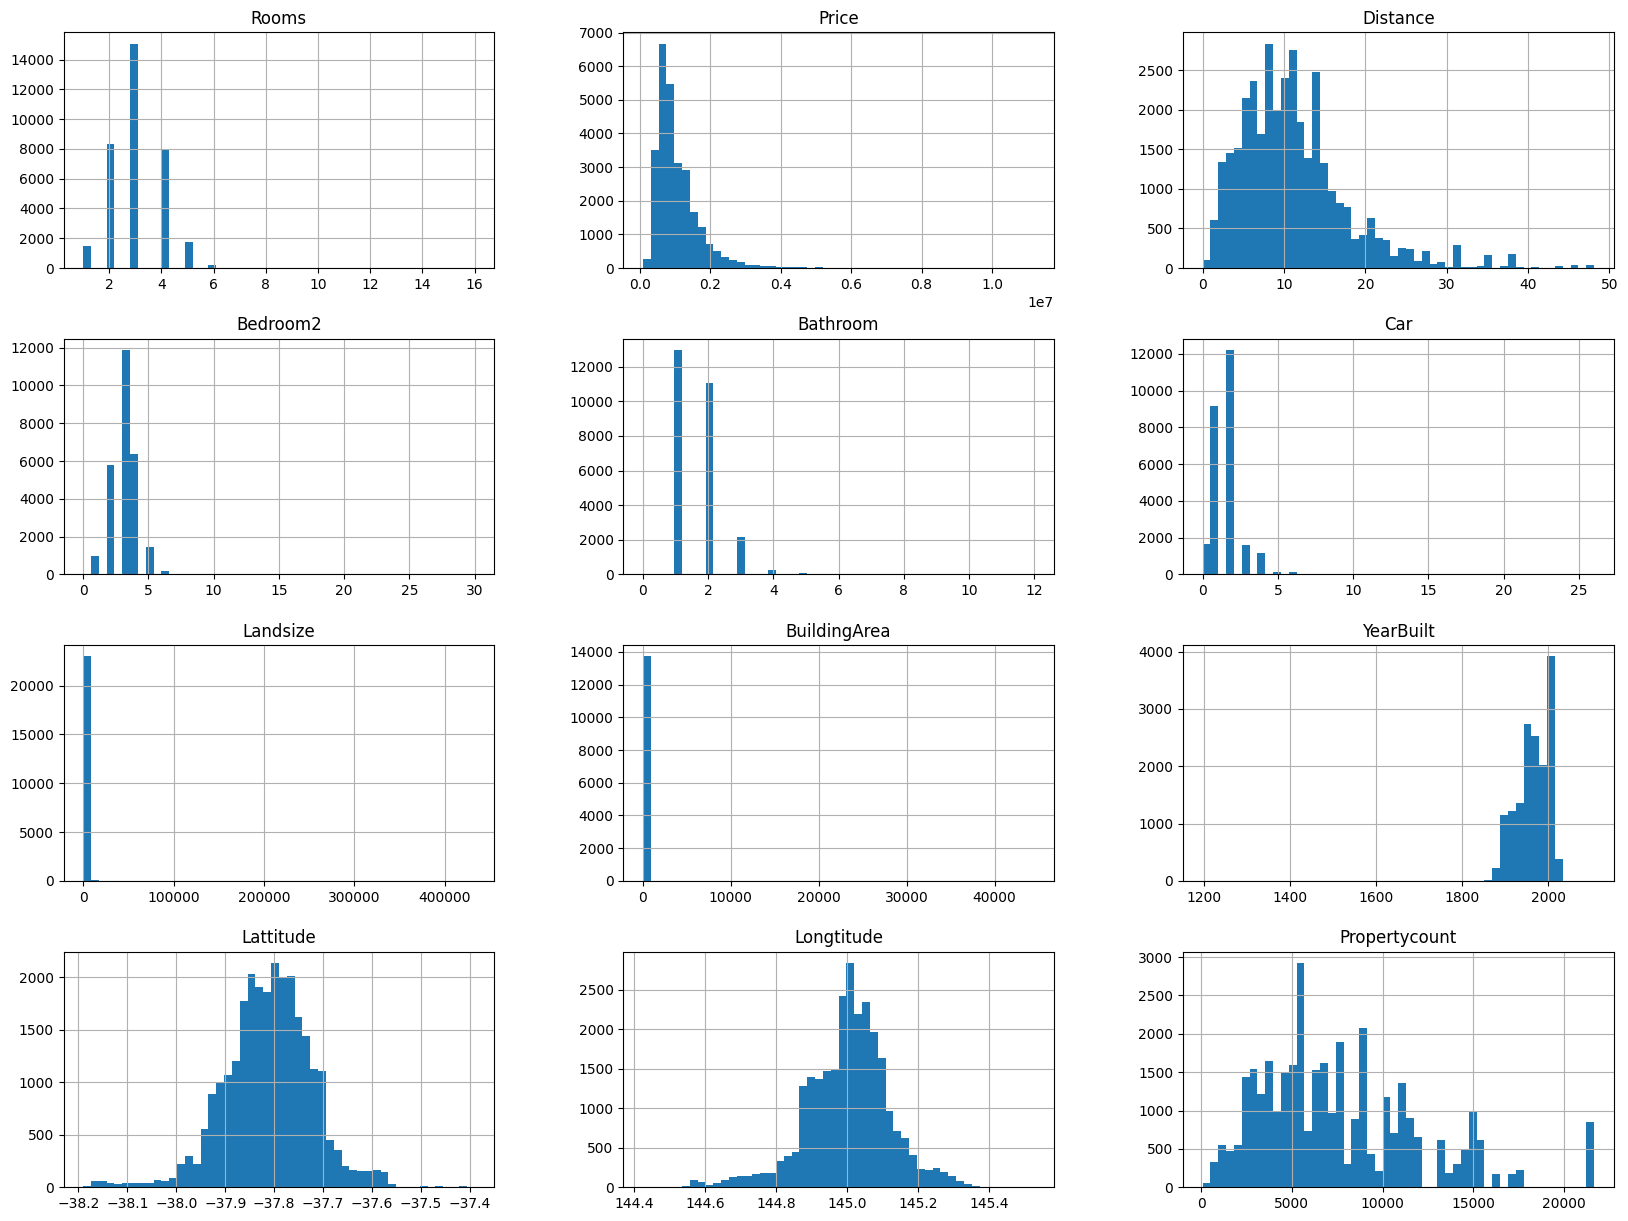

In [ ]:
housing.hist(["Rooms","Price","Distance","Bedroom2","Bathroom","Car","Landsize","BuildingArea","YearBuilt", "Lattitude", "Longtitude", "Propertycount"],bins = 50, figsize=(20,15))
plt.show()

Cool histograms 

### **Cleaning, Fixing, Engineering**

Starting off with the date column, this is a column that is very "feature engineerable". We will add three new columns.

We can separate the date into years, months and days, and see how many houses were sold in each particular category

In [ ]:
housing["Date"] = pd.to_datetime(housing["Date"], format = "%d/%m/%Y") #change the format to day-month-year
print(housing['Date'].dtype)

datetime64[ns]


In [ ]:
housing['Month_Sold'] = housing['Date'].dt.month
housing['Year_Sold'] = housing['Date'].dt.year
housing['Day_Sold'] = housing['Date'].dt.day_name()
housing['Date'] = housing['Date'].astype(str)

cat_cols.append('Day_Sold')

We'll also create a new "BuildingAge" column:

In [ ]:
housing['BuildingAge'] = datetime.date.today().year - housing['YearBuilt']
num_cols.append('BuildingAge')

In [ ]:
housing.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Longtitude,Regionname,Propertycount,Year,Month,Day,Month_Sold,Year_Sold,Day_Sold,BuildingAge
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,2016-09-03,2.5,3067.0,...,144.9958,Northern Metropolitan,4019.0,2016,9,3,9,2016,Saturday,NaN
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,144.9984,Northern Metropolitan,4019.0,2016,12,3,12,2016,Saturday,NaN
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,144.9934,Northern Metropolitan,4019.0,2016,2,4,2,2016,Thursday,126.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,2016-02-04,2.5,3067.0,...,145.0116,Northern Metropolitan,4019.0,2016,2,4,2,2016,Thursday,NaN
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,...,144.9944,Northern Metropolitan,4019.0,2017,3,4,3,2017,Saturday,126.0


In [ ]:
housing["Year_Sold"].value_counts()

Year_Sold
2017    19852
2016    10292
2018     4713
Name: count, dtype: int64

In [ ]:
housing["Month_Sold"].value_counts().sort_index(ascending=True)

Month_Sold
1      821
2     2642
3     3094
4     1520
5     3416
6     3175
7     2959
8     2888
9     4128
10    3900
11    4387
12    1927
Name: count, dtype: int64

In [ ]:
housing["Day_Sold"].value_counts()

Day_Sold
Saturday    31711
Sunday       1944
Monday        956
Tuesday       199
Thursday       47
Name: count, dtype: int64

It seems like most houses were sold on weekends, with none being sold on Wednesday and Friday.

### **Let's get rid of that duplicate row**

The "low hanging fruit" so to speak

In [ ]:
housing.drop_duplicates(inplace=True, keep="first")

### **Missing Values**

Here comes the "high hanging fruit" 